# 1. Regression with Concrete Compressive Strength

Universidad de Zaragoza

Names: Jorge Ruiz González & Hugo López Sola

NIAs: 826685, 875455

This is the notebook to train regression models and evaluate the performance of the models using the Concrete Compressive Strength Dataset
https://archive-beta.ics.uci.edu/dataset/165/concrete+compressive+strength

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rmcantin/datasets/refs/heads/main/concrete.csv")
df

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [2]:
# Split the inputs X with respect to the target variable y
X = df.drop(columns=["strength"])
y = df["strength"]
print(X.shape, y.shape)

# Use StandardScaler to scale the input features after splitting the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

(1030, 8) (1030,)


## 1.1 Split the data 
First of all, after you have your data, split it into the training, validation and test sets. Make 
sure you do not look at the test set until you report your final metrics

In [3]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (70%), validation (20%), and test (10%) sets

# For that purpose, we first split the dataset into training (70%) and temporary (30%) sets, and then we split the
# temporary set into validation (20%) and test (10%) sets.
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)

# Fit the scaler on training data only.
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

## 1.2 Explore the data 
Report first the size of the problem (how many samples are in the dataset. How many 
dimensions does your data have?). 
Plot and/or analyze in more depth the relation of each dimension with the output. For 
example, for each input variable and the output, 1) compute the correlation (you can use the 
numpy function corrcoef) and 2) plot the relation between the two variables in a 2-d graph 
(you can use the pyplot function scatter).

Training set: 721 samples, 8 dimensions
Validation set: 206 samples, 8 dimensions
Test set: 103 samples, 8 dimensions
Total: 1030 samples


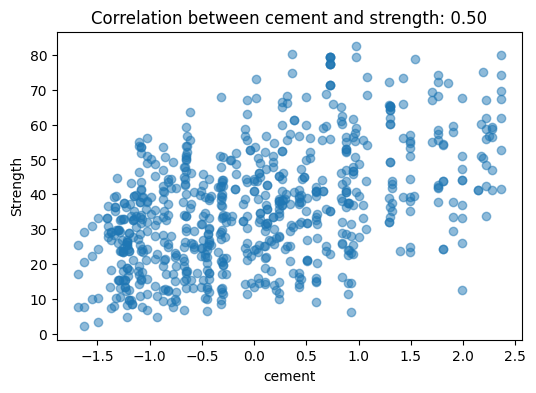

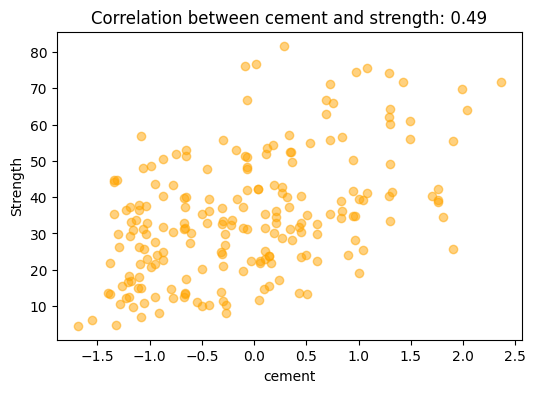

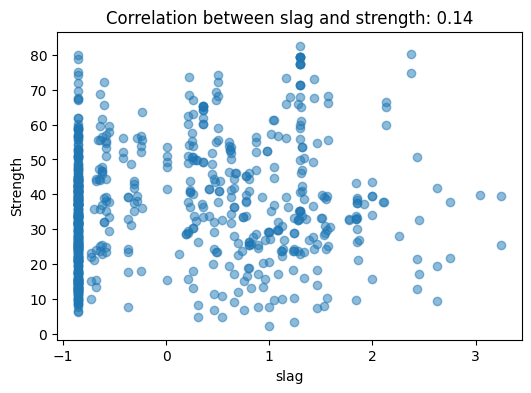

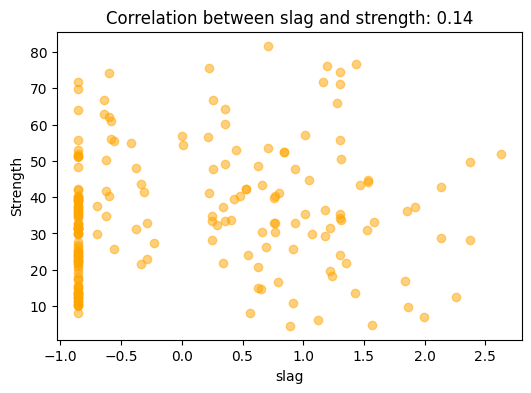

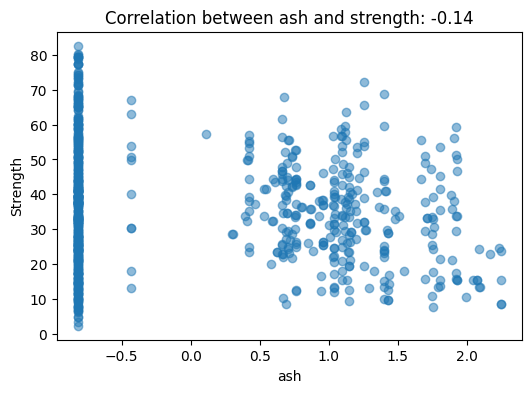

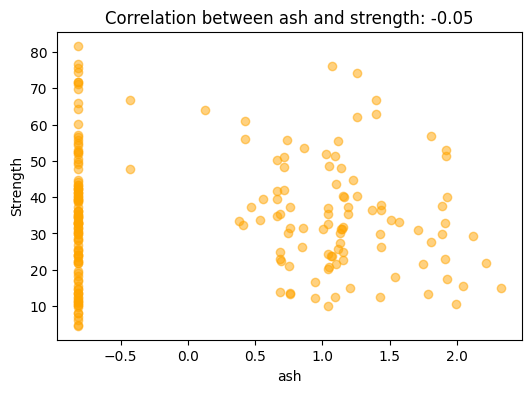

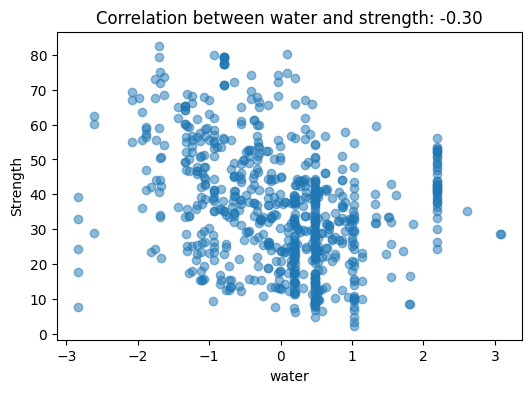

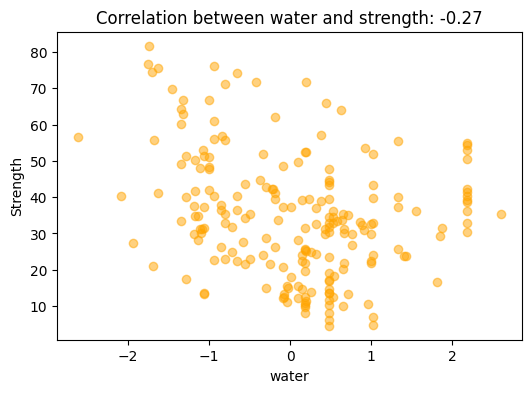

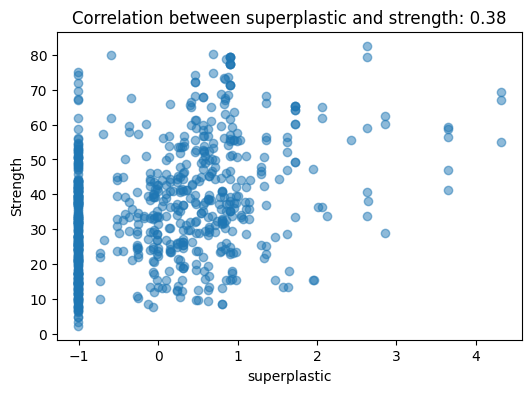

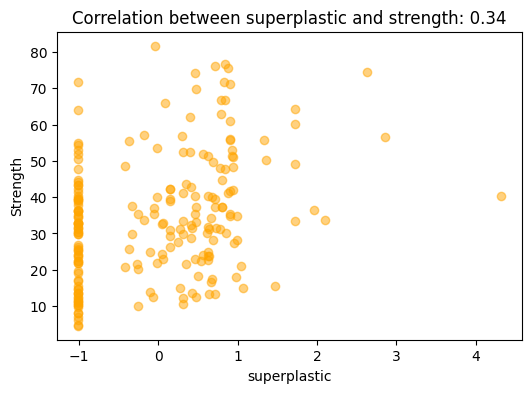

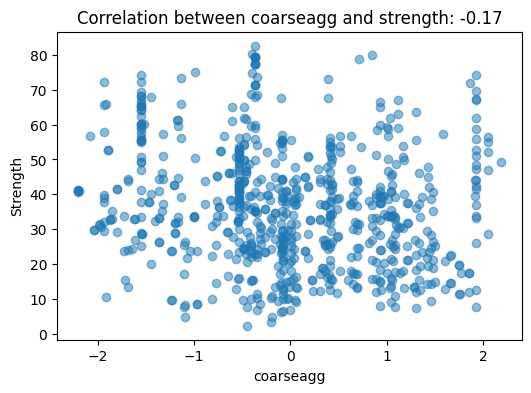

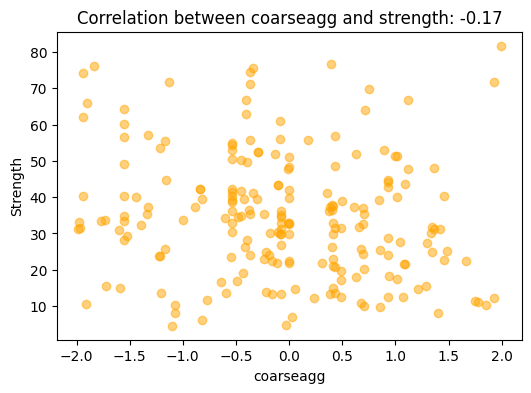

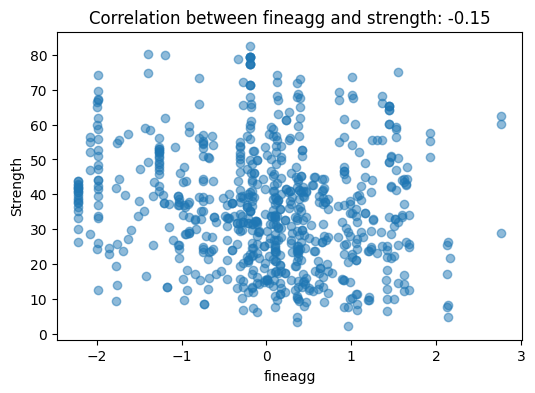

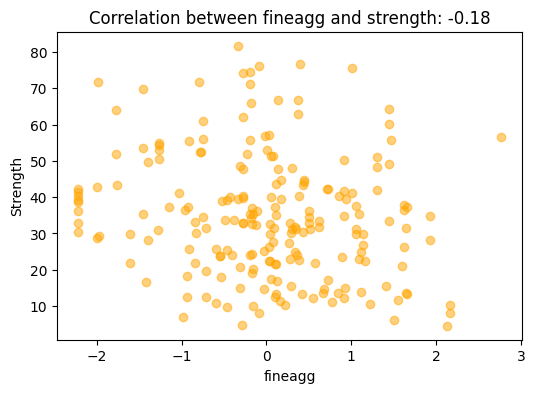

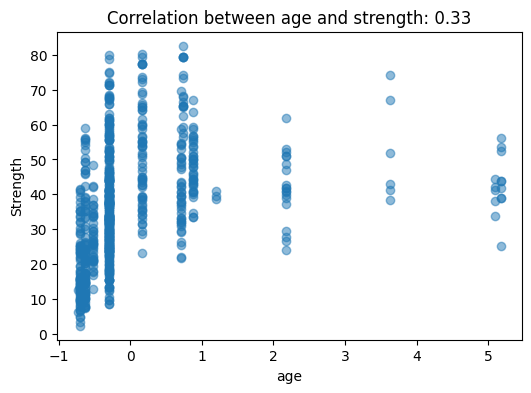

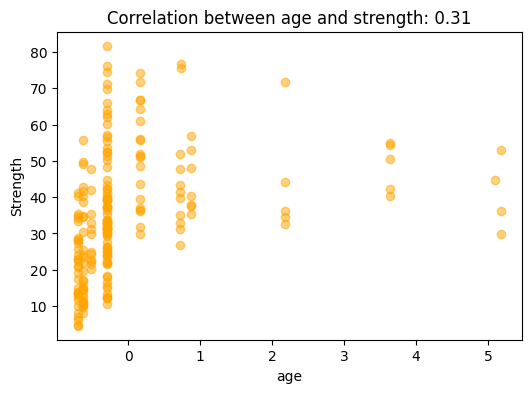

In [4]:
# Data Exploration

# For each train, validation, and test set, we print the number of samples and features.
n_samples_train, n_dim = X_train.shape
n_samples_val, _ = X_val.shape
n_samples_test, _ = X_test.shape
n_samples_total = n_samples_train + n_samples_val + n_samples_test

print(f"Training set: {n_samples_train} samples, {n_dim} dimensions")
print(f"Validation set: {n_samples_val} samples, {n_dim} dimensions")
print(f"Test set: {n_samples_test} samples, {n_dim} dimensions")
print(f"Total: {n_samples_total} samples", end="\n")

# Analysis of the relation of each dimension with the output. For each input variable, compute the correlation and plot
# the relation between the two variables in a 2D graph.
from numpy import corrcoef
from matplotlib import pyplot as plt

for i in range(n_dim):

    feature_name = X.columns[i]

    # Correlation between the input variable and the output variable for the training set (blue)
    correlation_matrix = corrcoef(X_train[:, i], y_train)
    correlation = correlation_matrix[0, 1]
    plt.figure(figsize=(6, 4))
    plt.scatter(X_train[:, i], y_train, alpha=0.5)
    plt.title(f"Correlation between {feature_name} and strength: {correlation:.2f}")
    plt.xlabel(feature_name)
    plt.ylabel("Strength")
    plt.show()

    # Correlation between the input variable and the output variable for the validation set (orange)
    correlation_matrix = corrcoef(X_val[:, i], y_val)
    correlation = correlation_matrix[0, 1]
    plt.figure(figsize=(6, 4))
    plt.scatter(X_val[:, i], y_val, c='orange', alpha=0.5)
    plt.title(f"Correlation between {feature_name} and strength: {correlation:.2f}")
    plt.xlabel(feature_name)
    plt.ylabel("Strength")
    plt.show()


In [5]:
# Pearson correlation between each feature and strength (training data only)
correlations = X_train_raw.corrwith(y_train).sort_values(
    key=lambda values: values.abs(), ascending=False
)
correlation_table = correlations.rename(
    "Pearson r with strength"
).to_frame()
correlation_table.index.name = "Feature"
display(correlation_table.round(3))


,Pearson r with strength
Feature,
cement,0.497
superplastic,0.377
age,0.328
water,-0.301
coarseagg,-0.173
fineagg,-0.149
slag,0.144
ash,-0.137



Cement and superplasticizer have positive correlations with strength, while water has a
negative correlation. The spread suggests that several inputs and nonlinear relations matter.

We keep zero superplasticizer values: zero can mean that no additive was used, so it is not
automatically an outlier.


## 1.3 Train several promising models, decide on the best one and report expected performance 
Train the regression models we have seen in class (linear regression, polynomial models, 
ridge/Huber regression, RANSAC...) and others if you want to. If training is slow, consider 
doing quick explorations reducing the dataset size or the data dimensionality. Report several 
metrics and analyze their values. Extract conclusions and explain the results.

In [6]:
# Firstly we choose the metrics to evaluate the performance of each model.

# ----------------------------------------------------------------------------------------------------------------------
# MAE: Mean Absolute Error
# MedAE: Median Absolute Error
# MSE: Mean Squared Error
# RMSE: Root Mean Squared Error
# R2: R-squared
# ----------------------------------------------------------------------------------------------------------------------

# Function that given a model and the training and validation sets, fits the model to the training set and evaluates it
# on the validation set, returning the metrics.
# ----------------------------------------------------------------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    medae = median_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    return mae, medae, mse, rmse, r2

# Function that given a model and the metrics obtained, add the results to a pandas dataframe (2 decimals) and returns
# the updated dataframe.
# ----------------------------------------------------------------------------------------------------------------------
def add_results(dataframe, model_name, mae, medae, mse, rmse, r2):
    new_row = pd.DataFrame({
        "Model": [model_name],
        "MAE": [round(mae, 2)],
        "MedAE": [round(medae, 2)],
        "MSE": [round(mse, 2)],
        "RMSE": [round(rmse, 2)],
        "R2": [round(r2, 2)]
    })
    return pd.concat([dataframe, new_row], ignore_index=True)

# Dataframe to store the results of each model.
results = pd.DataFrame(columns=["Model", "MAE", "MedAE", "MSE", "RMSE", "R2"])

In [7]:
## Model 1: Linear Regression
# ----------------------------------------------------------------------------------------------------------------------
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
mae_model_1, medae_model_1, mse_model_1, rmse_model_1, r2_model_1 = evaluate(model_1, X_train, y_train, X_val, y_val)
results = add_results(results, "Linear Regression", mae_model_1, medae_model_1, mse_model_1, rmse_model_1, r2_model_1)

# Print the results of the models in a table.
print(results)

               Model   MAE  MedAE     MSE   RMSE   R2
0  Linear Regression  8.47   6.61  113.44  10.65  0.6


C:\Users\JORGE\AppData\Local\Temp\ipykernel_2880\1034716884.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([dataframe, new_row], ignore_index=True)


In [8]:
## Model 2: Polynomial Regression
# ----------------------------------------------------------------------------------------------------------------------

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# We are using Cross-Validation to find the best degree of the polynomial regression model.
degrees = [2, 3, 4]
cv_scores = []

for degree in degrees:
    print(f"Testing degree: {degree}")
    
    poly_reg = make_pipeline(StandardScaler(), PolynomialFeatures(degree), LinearRegression())
    scores = cross_val_score(poly_reg, X_train_raw, y_train, cv=5, scoring='r2')
    print(f"Average CV score: {np.mean(scores)}")
    print()
    cv_scores.append(scores)

# Find the best degree based on the highest average CV score
best_degree = degrees[np.argmax([np.mean(s) for s in cv_scores])]
print(f"Best degree: {best_degree}")

Testing degree: 2
Average CV score: 0.7745175455170107

Testing degree: 3
Average CV score: 0.7384976735474755

Testing degree: 4


Average CV score: -1516688.6842637197

Best degree: 2


In [9]:
# Evaluate the best polynomial regression model on the validation set
poly_reg_best = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())

mae_model_2, medae_model_2, mse_model_2, rmse_model_2, r2_model_2 = evaluate(poly_reg_best, X_train, y_train, X_val, y_val)
results = add_results(results, f"Polynomial Regression (deg={best_degree})", mae_model_2, medae_model_2, mse_model_2, rmse_model_2, r2_model_2)

print(results)

                           Model   MAE  MedAE     MSE   RMSE    R2
0              Linear Regression  8.47   6.61  113.44  10.65  0.60
1  Polynomial Regression (deg=2)  5.99   4.81   61.01   7.81  0.79


In [10]:
## Model 3: Polynomial Regression with L2 Regularization (Ridge Regression)
# ----------------------------------------------------------------------------------------------------------------------

# As in the previous model, we are using Cross-Validation to find the best degree of the polynomial regression model.
# This time we also need to use Cross-Validation to find the best regularization parameter alpha

degrees = [2, 3]
alphas = [0.1, 1, 10]

results_ridge = pd.DataFrame(columns=["Degree", "Alpha", "Average CV Score"])

# We use cross-validation to compare each combination of degree and alpha
from sklearn.linear_model import Ridge

for degree in degrees:
    for alpha in alphas:
        print(f"Testing degree: {degree}, alpha: {alpha}")
        
        poly_reg_ridge = make_pipeline(StandardScaler(), PolynomialFeatures(degree), Ridge(alpha=alpha))
        scores = cross_val_score(poly_reg_ridge, X_train_raw, y_train, cv=5, scoring='r2')

        results_ridge = pd.concat([results_ridge, pd.DataFrame({
            "Degree": [degree],
            "Alpha": [alpha],
            "Average CV Score": [np.mean(scores)]
        })], ignore_index=True)

print(results_ridge)

# Find the best combination of degree and alpha based on the highest average CV score
best_row = results_ridge.loc[results_ridge["Average CV Score"].idxmax()]
best_degree_ridge = int(best_row["Degree"])
best_alpha_ridge = float(best_row["Alpha"])

print(f"Best degree: {best_degree_ridge}, Best alpha: {best_alpha_ridge}")

Testing degree: 2, alpha: 0.1
Testing degree: 2, alpha: 1
Testing degree: 2, alpha: 10
Testing degree: 3, alpha: 0.1


C:\Users\JORGE\AppData\Local\Temp\ipykernel_2880\474088897.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_ridge = pd.concat([results_ridge, pd.DataFrame({


Testing degree: 3, alpha: 1
Testing degree: 3, alpha: 10
  Degree  Alpha  Average CV Score
0      2    0.1          0.774879
1      2    1.0          0.775229
2      2   10.0          0.771621
3      3    0.1          0.793082
4      3    1.0          0.819172
5      3   10.0          0.838480
Best degree: 3, Best alpha: 10.0


In [11]:
# Evaluate the best polynomial Ridge model on the validation set
poly_reg_ridge_best = make_pipeline(
    PolynomialFeatures(best_degree_ridge), Ridge(alpha=best_alpha_ridge))

mae_model_3, medae_model_3, mse_model_3, rmse_model_3, r2_model_3 = evaluate(
    poly_reg_ridge_best, X_train, y_train, X_val, y_val)
results = add_results(results, f"Polynomial Ridge (deg={best_degree_ridge}, alpha={best_alpha_ridge})",
                      mae_model_3, medae_model_3, mse_model_3, rmse_model_3, r2_model_3)
print(results)

                                  Model   MAE  MedAE     MSE   RMSE    R2
0                     Linear Regression  8.47   6.61  113.44  10.65  0.60
1         Polynomial Regression (deg=2)  5.99   4.81   61.01   7.81  0.79
2  Polynomial Ridge (deg=3, alpha=10.0)  4.95   4.07   42.34   6.51  0.85


In [12]:
## Model 4: Huber Regression
# ----------------------------------------------------------------------------------------------------------------------
from sklearn.linear_model import HuberRegressor

model_4 = HuberRegressor(max_iter=2000)
mae_model_4, medae_model_4, mse_model_4, rmse_model_4, r2_model_4 = evaluate(
    model_4, X_train, y_train, X_val, y_val)
results = add_results(results, "Huber Regression",
                      mae_model_4, medae_model_4, mse_model_4, rmse_model_4, r2_model_4)
print(results)

                                  Model   MAE  MedAE     MSE   RMSE    R2
0                     Linear Regression  8.47   6.61  113.44  10.65  0.60
1         Polynomial Regression (deg=2)  5.99   4.81   61.01   7.81  0.79
2  Polynomial Ridge (deg=3, alpha=10.0)  4.95   4.07   42.34   6.51  0.85
3                      Huber Regression  8.32   6.36  118.83  10.90  0.58


In [13]:
## Model 5: RANSAC Regression
# ----------------------------------------------------------------------------------------------------------------------
from sklearn.linear_model import RANSACRegressor

model_5 = RANSACRegressor(random_state=42)
mae_model_5, medae_model_5, mse_model_5, rmse_model_5, r2_model_5 = evaluate(
    model_5, X_train, y_train, X_val, y_val)
results = add_results(results, "RANSAC Regression",
                      mae_model_5, medae_model_5, mse_model_5, rmse_model_5, r2_model_5)
print(results)

                                  Model    MAE  MedAE     MSE   RMSE    R2
0                     Linear Regression   8.47   6.61  113.44  10.65  0.60
1         Polynomial Regression (deg=2)   5.99   4.81   61.01   7.81  0.79
2  Polynomial Ridge (deg=3, alpha=10.0)   4.95   4.07   42.34   6.51  0.85
3                      Huber Regression   8.32   6.36  118.83  10.90  0.58
4                     RANSAC Regression  10.32   6.08  347.78  18.65 -0.22


Polynomial features describe nonlinear relations while keeping the model linear in its
coefficients. Ridge limits large coefficients; Huber and RANSAC reduce the influence of
outliers. These are the approaches discussed in **1.2 Shallow Learning**.

We select the model with the lowest validation RMSE. RMSE gives more weight to large
errors than MAE, while MedAE is less affected by outliers.

In [14]:
# Select the best model using validation RMSE.
models = {
    "Linear Regression": model_1,
    "Polynomial Regression": poly_reg_best,
    "Polynomial Ridge": poly_reg_ridge_best,
    "Huber Regression": model_4,
    "RANSAC Regression": model_5
}
best_rmse = np.inf

for name, model in models.items():
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
    if val_rmse < best_rmse:
        best_rmse = val_rmse
        best_name = name
        best_model = model

print(f"Best model: {best_name}")
print(f"Validation RMSE: {best_rmse:.2f} MPa")
print(results.sort_values("RMSE"))

Best model: Polynomial Ridge
Validation RMSE: 6.51 MPa
                                  Model    MAE  MedAE     MSE   RMSE    R2
2  Polynomial Ridge (deg=3, alpha=10.0)   4.95   4.07   42.34   6.51  0.85
1         Polynomial Regression (deg=2)   5.99   4.81   61.01   7.81  0.79
0                     Linear Regression   8.47   6.61  113.44  10.65  0.60
3                      Huber Regression   8.32   6.36  118.83  10.90  0.58
4                     RANSAC Regression  10.32   6.08  347.78  18.65 -0.22


In [15]:
# Final evaluation on the test set
y_pred_test = best_model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
medae_test = median_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

test_results = pd.DataFrame(columns=results.columns)
test_results = add_results(test_results, best_name, mae_test, medae_test, mse_test, rmse_test, r2_test)
print(test_results)
print(f"The selected model has an average absolute error of {mae_test:.2f} MPa "
      f"and a test R2 of {r2_test:.3f}.")

              Model  MAE  MedAE    MSE  RMSE   R2
0  Polynomial Ridge  5.2   4.25  49.16  7.01  0.8
The selected model has an average absolute error of 5.20 MPa and a test R2 of 0.798.


C:\Users\JORGE\AppData\Local\Temp\ipykernel_2880\1034716884.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([dataframe, new_row], ignore_index=True)


## 1.4 High dimensional data
We use the Superconductivity dataset, with 81 features, to predict critical temperature.
We compare linear regression, Ridge and PCA + Ridge, and study the effect of training size.
PCA keeps directions with high input variance, as seen in the lecture slides.

In [16]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

X_sc, y_sc = fetch_openml(data_id=44964, as_frame=True, return_X_y=True)
y_sc = y_sc.astype(float)

X_sc_train, X_sc_temp, y_sc_train, y_sc_temp = train_test_split(
    X_sc, y_sc, test_size=0.3, random_state=42)
X_sc_val, X_sc_test, y_sc_val, y_sc_test = train_test_split(
    X_sc_temp, y_sc_temp, test_size=1/3, random_state=42)

print(f"Dataset: {len(X_sc)} samples and {X_sc.shape[1]} features")
print(f"Training: {len(X_sc_train)}, validation: {len(X_sc_val)}, test: {len(X_sc_test)}")

Dataset: 21263 samples and 81 features
Training: 14884, validation: 4252, test: 2127


In [17]:
models_sc = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1)),
    "PCA + Ridge": make_pipeline(StandardScaler(), PCA(n_components=0.95), Ridge(alpha=1))
}
results_sc = pd.DataFrame(columns=results.columns)
best_rmse_sc = np.inf

for name, model in models_sc.items():
    mae, medae, mse, rmse, r2 = evaluate(model, X_sc_train, y_sc_train, X_sc_val, y_sc_val)
    results_sc = add_results(results_sc, name, mae, medae, mse, rmse, r2)
    if rmse < best_rmse_sc:
        best_rmse_sc = rmse
        best_name_sc = name

print(results_sc)
print("PCA components:", models_sc["PCA + Ridge"].named_steps["pca"].n_components_)
print("Best model on validation:", best_name_sc)

               Model    MAE  MedAE     MSE   RMSE    R2
0  Linear Regression  13.57  10.48  321.19  17.92  0.73
1              Ridge  13.58  10.49  322.00  17.94  0.73
2        PCA + Ridge  17.37  14.75  483.68  21.99  0.59
PCA components: 17
Best model on validation: Linear Regression


C:\Users\JORGE\AppData\Local\Temp\ipykernel_2880\1034716884.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([dataframe, new_row], ignore_index=True)


In [18]:
# Search alpha for Ridge and alpha/components for PCA + Ridge.
# GridSearchCV fits scaling and PCA within each fold and uses training data only.
from sklearn.model_selection import GridSearchCV

ridge_tuning = GridSearchCV(
    make_pipeline(StandardScaler(), Ridge()),
    {"ridge__alpha": [0.01, 0.1, 1, 10, 100]},
    scoring="neg_mean_squared_error", cv=3, n_jobs=1
)
ridge_tuning.fit(X_sc_train, y_sc_train)

pca_ridge_tuning = GridSearchCV(
    make_pipeline(StandardScaler(), PCA(), Ridge()),
    {
        "pca__n_components": [5, 10, 17, 30, 50, 0.95, 0.99],
        "ridge__alpha": [0.01, 0.1, 1, 10, 100],
    },
    scoring="neg_mean_squared_error", cv=3, n_jobs=1
)
pca_ridge_tuning.fit(X_sc_train, y_sc_train)

tuned_candidates = {
    "Linear Regression": models_sc["Linear Regression"],
    "Ridge (alpha=1)": models_sc["Ridge"],
    "PCA + Ridge (95%, alpha=1)": models_sc["PCA + Ridge"],
    "Ridge (CV tuned)": ridge_tuning.best_estimator_,
    "PCA + Ridge (CV tuned)": pca_ridge_tuning.best_estimator_,
}
tuned_rows = []
for name, model in tuned_candidates.items():
    y_val_pred = model.predict(X_sc_val)
    tuned_rows.append({
        "Model": name,
        "Validation RMSE": np.sqrt(mean_squared_error(y_sc_val, y_val_pred)),
        "Validation R2": r2_score(y_sc_val, y_val_pred),
    })
tuned_results = pd.DataFrame(tuned_rows).set_index("Model").sort_values("Validation RMSE")
print("Ridge best parameters:", ridge_tuning.best_params_)
print("Ridge CV RMSE:", np.sqrt(-ridge_tuning.best_score_))
print("PCA + Ridge best parameters:", pca_ridge_tuning.best_params_)
print("PCA + Ridge CV RMSE:", np.sqrt(-pca_ridge_tuning.best_score_))
display(tuned_results.round(3))

# Select a configuration using validation only; keep the test set untouched.
best_name_sc = tuned_results.index[0]
best_model_sc = tuned_candidates[best_name_sc]
print("Selected on validation:", best_name_sc)


Ridge best parameters: {'ridge__alpha': 0.1}
Ridge CV RMSE: 17.58235532817472
PCA + Ridge best parameters: {'pca__n_components': 50, 'ridge__alpha': 10}
PCA + Ridge CV RMSE: 18.61236138284117


,Validation RMSE,Validation R2
Model,,
Linear Regression,17.922,0.726
Ridge (CV tuned),17.925,0.726
Ridge (alpha=1),17.944,0.725
PCA + Ridge (CV tuned),18.973,0.693
"PCA + Ridge (95%, alpha=1)",21.993,0.587


Selected on validation: Linear Regression


                Model  Training samples  Validation RMSE
0   Linear Regression               500            19.21
1               Ridge               500            18.95
2         PCA + Ridge               500            22.30
3   Linear Regression              2000            18.17
4               Ridge              2000            18.21
5         PCA + Ridge              2000            22.09
6   Linear Regression              5000            18.01
7               Ridge              5000            18.06
8         PCA + Ridge              5000            22.06
9   Linear Regression             14884            17.92
10              Ridge             14884            17.94
11        PCA + Ridge             14884            21.99


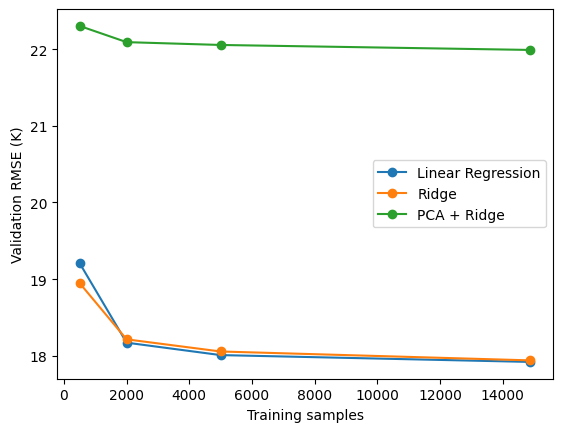

In [19]:
# Compare training sizes while keeping the validation set fixed.
size_results = []

for size in [500, 2000, 5000]:
    X_small, _, y_small, _ = train_test_split(
        X_sc_train, y_sc_train, train_size=size, random_state=42)
    for name, model in models_sc.items():
        mae, medae, mse, rmse, r2 = evaluate(model, X_small, y_small, X_sc_val, y_sc_val)
        size_results.append({"Model": name, "Training samples": size, "Validation RMSE": rmse})

for _, row in results_sc.iterrows():
    size_results.append({"Model": row["Model"], "Training samples": len(X_sc_train),
                         "Validation RMSE": row["RMSE"]})

size_results = pd.DataFrame(size_results)
print(size_results.round(2))

for name in models_sc:
    values = size_results[size_results["Model"] == name]
    plt.plot(values["Training samples"], values["Validation RMSE"], "o-", label=name)
plt.xlabel("Training samples")
plt.ylabel("Validation RMSE (K)")
plt.legend()
plt.show()

More training data can reduce variance, but it does not remove the limitations of a linear
model. PCA reduces the number of inputs; we check validation error because keeping most input
variance does not guarantee better predictions.

In [20]:
# Refit the selected model on all training data after the data-size experiment.
mae, medae, mse, rmse, r2 = evaluate(
    best_model_sc, X_sc_train, y_sc_train, X_sc_test, y_sc_test)
test_results_sc = pd.DataFrame(columns=results.columns)
test_results_sc = add_results(test_results_sc, best_name_sc, mae, medae, mse, rmse, r2)
print(test_results_sc)
print(f"The selected model has a test RMSE of {rmse:.2f} K and R2 of {r2:.3f}.")

               Model    MAE  MedAE     MSE   RMSE    R2
0  Linear Regression  13.13   9.89  304.26  17.44  0.73
The selected model has a test RMSE of 17.44 K and R2 of 0.733.


C:\Users\JORGE\AppData\Local\Temp\ipykernel_2880\1034716884.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([dataframe, new_row], ignore_index=True)
